# EDA-08 · Kenh So & Thanh Toan (Digital Channels & Payment)
**Web Traffic & Conversion Proxy** · **Device & Order Source Mix** · **Payment Behaviour & Installment Uptake**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,
                     'grid.alpha':0.3,'font.size':10})

orders = pd.read_csv('orders.csv',       parse_dates=['order_date'])
items  = pd.read_csv('order_items.csv',  low_memory=False)
pays   = pd.read_csv('payments.csv')
web    = pd.read_csv('web_traffic.csv',  parse_dates=['date'])

# Basket size per order
items['basket_line'] = items['quantity'] * items['unit_price']
ord_basket = (items.groupby('order_id')['basket_line'].sum()
              .reset_index().rename(columns={'basket_line':'basket_size'}))

# Enrich orders
ord_full = orders.merge(ord_basket, on='order_id', how='left')
ord_full = ord_full.merge(pays[['order_id','payment_value','installments']], on='order_id', how='left')
ord_full['year']  = ord_full['order_date'].dt.year
ord_full['month'] = ord_full['order_date'].dt.month
ord_full['date']  = ord_full['order_date'].dt.date

# Web traffic: daily total + by source
web['year']  = web['date'].dt.year
web['month'] = web['date'].dt.month

SOURCES = ['organic_search','paid_search','social_media','email_campaign','referral','direct']
SRC_COLORS = {
    'organic_search':'#27ae60','paid_search':'#e74c3c','social_media':'#9b59b6',
    'email_campaign':'#f39c12','referral':'#3498db','direct':'#95a5a6'
}
DEV_COLORS = {'desktop':'#4C72B0','mobile':'#DD8452','tablet':'#55A868'}
PAY_COLORS  = {'credit_card':'#4C72B0','cod':'#e74c3c','paypal':'#27ae60',
               'apple_pay':'#9b59b6','bank_transfer':'#f39c12'}

print(f'Orders       : {len(orders):,}  ({orders["order_date"].min().date()} - {orders["order_date"].max().date()})')
print(f'Web traffic  : {len(web):,} rows  ({web["date"].min().date()} - {web["date"].max().date()})')
print(f'Overlap      : 2013-01-01 - {min(orders["order_date"].max(), web["date"].max()).date()}')
print(f'Avg daily sessions : {web.groupby("date")["sessions"].sum().mean():,.0f}')
print(f'Avg daily orders   : {ord_full.groupby("date").size().mean():.1f}')
print()
print('Installments distribution:')
print(pays['installments'].value_counts().sort_index().to_string())


Orders       : 646,945  (2012-07-04 - 2022-12-31)
Web traffic  : 3,652 rows  (2013-01-01 - 2022-12-31)
Overlap      : 2013-01-01 - 2022-12-31
Avg daily sessions : 25,042
Avg daily orders   : 168.8

Installments distribution:
installments
1     262866
2       1094
3     218949
6     109910
12     54126


## Part 1 · Web Traffic & Implicit Conversion Proxy
> Khong co conversion rate truc tiep. **Conversion proxy** = don hang tu source X / sessions tu source X cung ngay. Day la lower-bound estimate vi 1 session co the dan den nhieu don hang.

In [2]:
# ── Annual web traffic by source ─────────────────────────────────────────────
web_yr_src = (web.groupby(['year','traffic_source'])
              .agg(sessions=('sessions','sum'), visitors=('unique_visitors','sum'),
                   pageviews=('page_views','sum'), bounce=('bounce_rate','mean'),
                   duration=('avg_session_duration_sec','mean'))
              .reset_index())
web_yr = web.groupby('year').agg(
    sessions=('sessions','sum'), visitors=('unique_visitors','sum'),
    pageviews=('page_views','sum'), bounce=('bounce_rate','mean'),
    duration=('avg_session_duration_sec','mean'),
).reset_index()
web_yr['pages_per_session'] = web_yr['pageviews'] / web_yr['sessions']

print('=== Annual Web Traffic ===')
print(web_yr[['year','sessions','visitors','pages_per_session','bounce','duration']].to_string(index=False))
print()

# ── Conversion proxy: orders / sessions per day x source ─────────────────────
# Match order_source -> traffic_source on same date
daily_orders_src = (ord_full[ord_full['year'] >= 2013]
                    .groupby(['date','order_source'])['order_id']
                    .count().reset_index())
daily_orders_src.columns = ['date','traffic_source','n_orders']
daily_orders_src['date'] = pd.to_datetime(daily_orders_src['date'])

daily_web_src = web[['date','traffic_source','sessions']].copy()
daily_conv = daily_web_src.merge(daily_orders_src, on=['date','traffic_source'], how='left')
daily_conv['n_orders'] = daily_conv['n_orders'].fillna(0)
daily_conv['conv_proxy'] = daily_conv['n_orders'] / daily_conv['sessions'].replace(0,np.nan) * 100
daily_conv['year'] = daily_conv['date'].dt.year

conv_yr_src = daily_conv.groupby(['year','traffic_source']).agg(
    sessions    = ('sessions','sum'),
    orders      = ('n_orders','sum'),
    conv_proxy  = ('conv_proxy','mean'),
).reset_index()
conv_yr_src['conv_agg'] = conv_yr_src['orders'] / conv_yr_src['sessions'] * 100

print('=== Conversion Proxy (orders/sessions %) by Year x Source ===')
conv_pivot = conv_yr_src.pivot(index='year', columns='traffic_source', values='conv_agg').round(3)
print(conv_pivot.to_string())
print()

# Overall annual conversion proxy
conv_yr = daily_conv.groupby('year').agg(
    total_sessions = ('sessions','sum'),
    total_orders   = ('n_orders','sum'),
).reset_index()
conv_yr['conv_proxy_pct'] = conv_yr['total_orders'] / conv_yr['total_sessions'] * 100
print('=== Overall Conversion Proxy by Year ===')
print(conv_yr.to_string(index=False))


=== Annual Web Traffic ===
 year  sessions  visitors  pages_per_session   bounce   duration
 2013   6801940   5166501           4.322834 0.004545 206.941644
 2014   7340960   5596248           4.351911 0.004450 212.567671
 2015   7861938   5962192           4.347006 0.004409 216.365479
 2016   8403399   6393654           4.322331 0.004425 205.377049
 2017   8992602   6818372           4.313094 0.004479 209.265205
 2018   9415085   7143496           4.403767 0.004528 208.406027
 2019   9990148   7580565           4.296944 0.004539 207.552329
 2020  10591082   8065367           4.357105 0.004546 213.418033
 2021  10991725   8367014           4.345166 0.004464 210.011507
 2022  11063658   8409280           4.314265 0.004489 212.932329



=== Conversion Proxy (orders/sessions %) by Year x Source ===


traffic_source  direct  email_campaign  organic_search  paid_search  referral  social_media
year                                                                                       
2013             0.106           0.145           0.314        0.224     0.115         0.219
2014             0.080           0.133           0.319        0.247     0.099         0.223
2015             0.095           0.110           0.314        0.223     0.106         0.208
2016             0.073           0.122           0.264        0.236     0.094         0.194
2017             0.066           0.106           0.220        0.174     0.084         0.185
2018             0.050           0.089           0.209        0.167     0.073         0.146
2019             0.033           0.050           0.118        0.093     0.040         0.080
2020             0.021           0.040           0.086        0.075     0.033         0.074
2021             0.029           0.041           0.089        0.065     0.028   

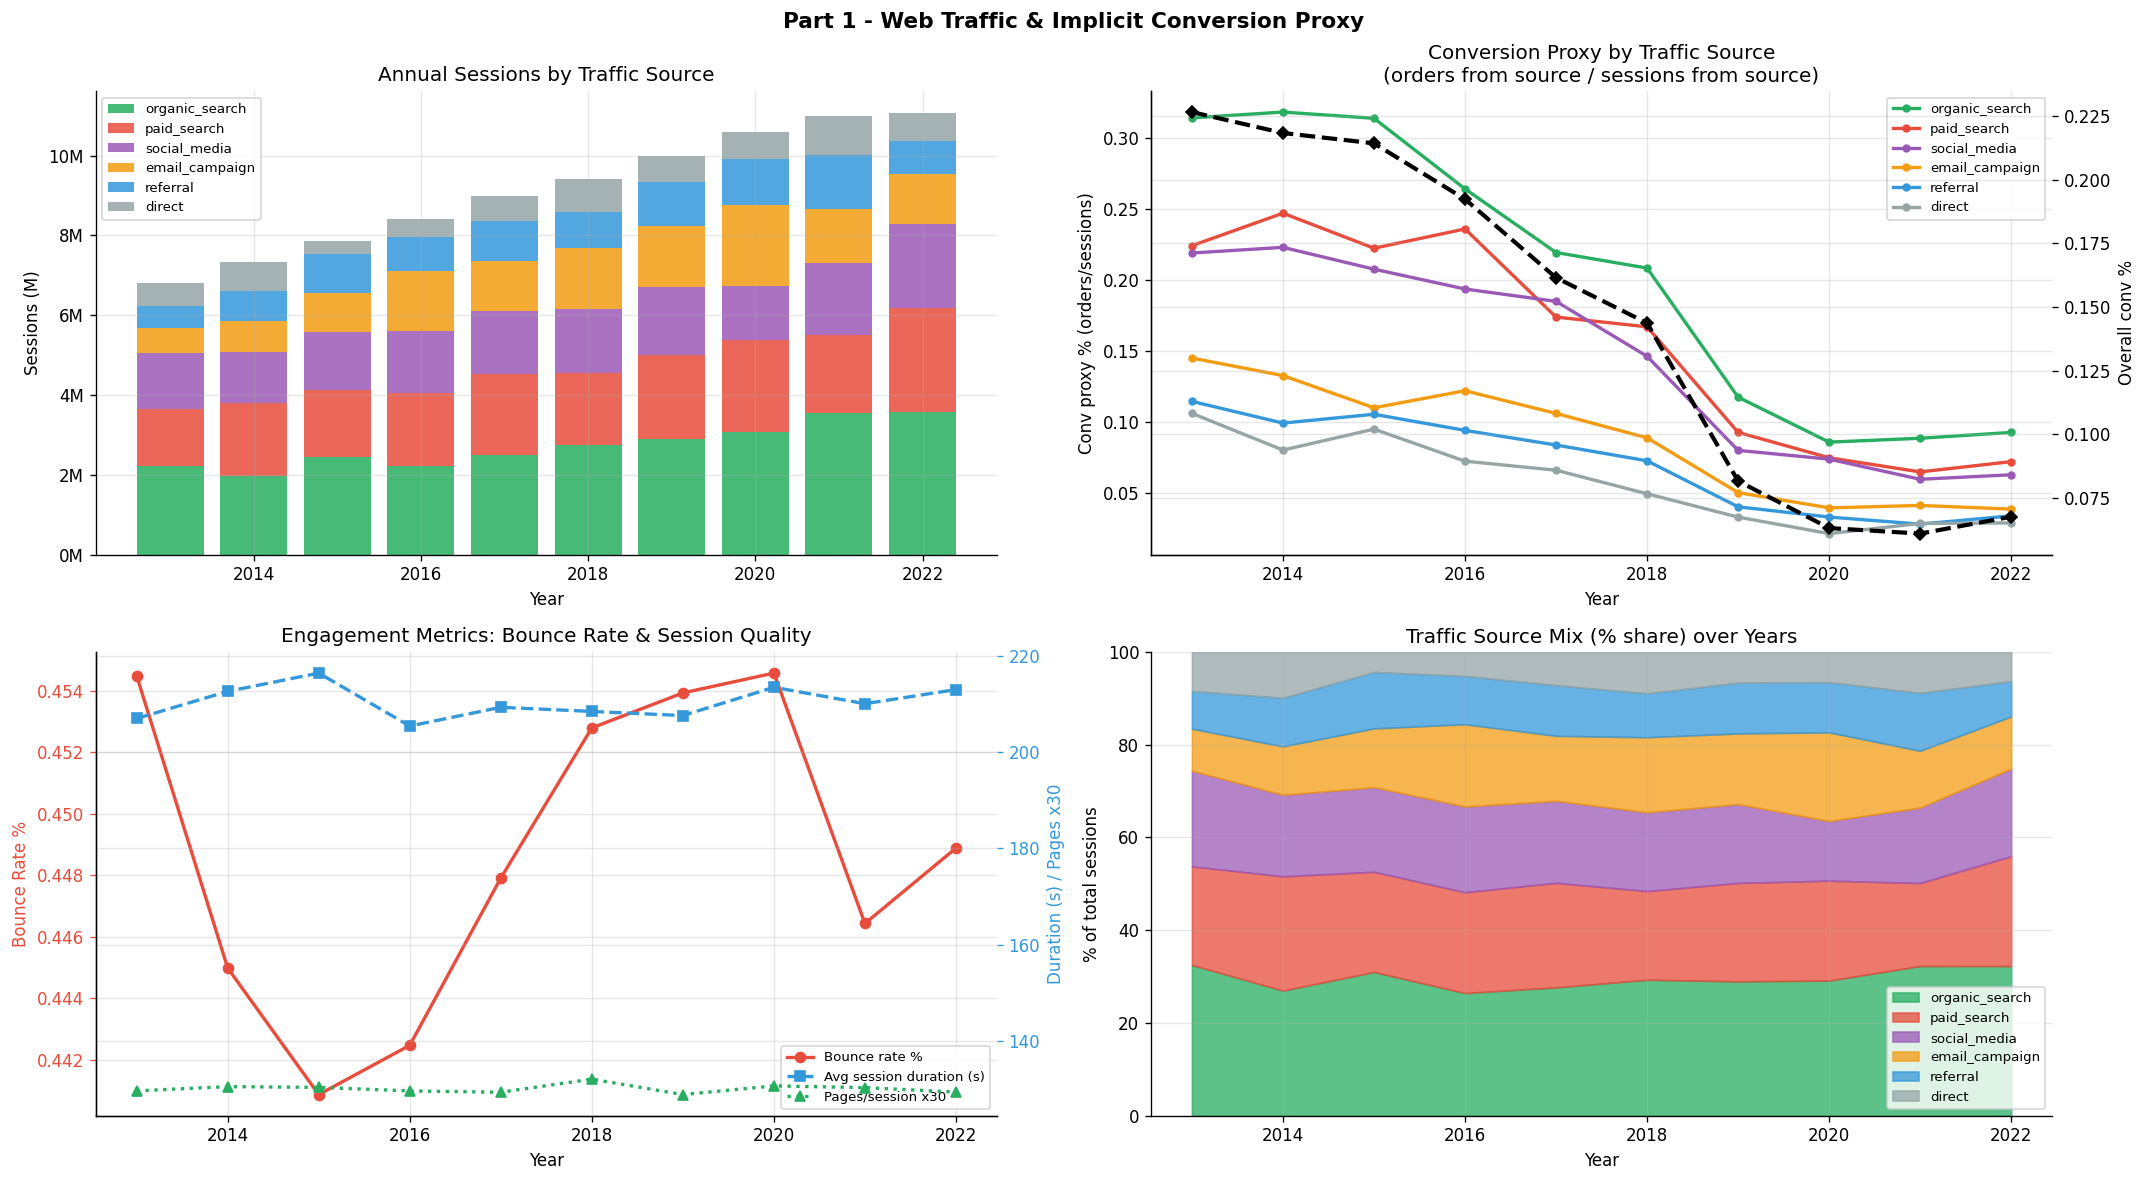

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# ── A: Sessions by source stacked bar ────────────────────────────────────────
ax = axes[0]
web_src_yr = web_yr_src.pivot(index='year', columns='traffic_source', values='sessions').fillna(0)
bottom = np.zeros(len(web_src_yr))
for src in SOURCES:
    if src not in web_src_yr.columns: continue
    vals = web_src_yr[src].values / 1e6
    ax.bar(web_src_yr.index, vals, bottom=bottom,
           color=SRC_COLORS.get(src,'#aaa'), alpha=0.85, label=src)
    bottom += vals
ax.set_xlabel('Year'); ax.set_ylabel('Sessions (M)')
ax.set_title('Annual Sessions by Traffic Source')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))

# ── B: Conversion proxy % by source (line chart) ─────────────────────────────
ax = axes[1]
for src in SOURCES:
    sub = conv_yr_src[conv_yr_src['traffic_source']==src]
    ax.plot(sub['year'], sub['conv_agg'], marker='o', ms=4, lw=2,
            color=SRC_COLORS.get(src,'#aaa'), label=src)
ax.set_xlabel('Year'); ax.set_ylabel('Conv proxy % (orders/sessions)')
ax.set_title('Conversion Proxy by Traffic Source\n(orders from source / sessions from source)')
ax.legend(fontsize=8)
ax2 = ax.twinx()
ax2.plot(conv_yr['year'], conv_yr['conv_proxy_pct'], color='black',
         lw=2.5, linestyle='--', marker='D', ms=5, label='Overall')
ax2.set_ylabel('Overall conv %', color='black')
ax2.tick_params(axis='y', colors='black')

# ── C: Bounce rate & session duration trend ───────────────────────────────────
ax = axes[2]
ax.plot(web_yr['year'], web_yr['bounce']*100, color='#e74c3c',
        marker='o', lw=2, label='Bounce rate %')
ax.set_ylabel('Bounce Rate %', color='#e74c3c')
ax.tick_params(axis='y', colors='#e74c3c')
ax.set_xlabel('Year')
ax2c = ax.twinx()
ax2c.plot(web_yr['year'], web_yr['duration'], color='#3498db',
          marker='s', lw=2, linestyle='--', label='Avg session duration (s)')
ax2c.plot(web_yr['year'], web_yr['pages_per_session']*30, color='#27ae60',
          marker='^', lw=2, linestyle=':', label='Pages/session x30')
ax2c.set_ylabel('Duration (s) / Pages x30', color='#3498db')
ax2c.tick_params(axis='y', colors='#3498db')
ax.set_title('Engagement Metrics: Bounce Rate & Session Quality')
lines1,labs1 = ax.get_legend_handles_labels()
lines2,labs2 = ax2c.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8)

# ── D: Source mix % over years (area chart) ───────────────────────────────────
ax = axes[3]
src_pct = web_src_yr.div(web_src_yr.sum(axis=1), axis=0) * 100
bottom2 = np.zeros(len(src_pct))
for src in SOURCES:
    if src not in src_pct.columns: continue
    vals2 = src_pct[src].values
    ax.fill_between(src_pct.index, bottom2, bottom2+vals2,
                    color=SRC_COLORS.get(src,'#aaa'), alpha=0.75, label=src)
    bottom2 += vals2
ax.set_xlabel('Year'); ax.set_ylabel('% of total sessions')
ax.set_title('Traffic Source Mix (% share) over Years')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 100)

plt.suptitle('Part 1 - Web Traffic & Implicit Conversion Proxy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dig_p1_traffic.png', bbox_inches='tight')
plt.show()


## Part 2 · Device & Order Source Mix by Year
> Xem xu huong mobile vs desktop, organic vs paid, va chat luong basket theo tung kenh.

In [4]:
# ── Device type by year ───────────────────────────────────────────────────────
dev_yr = (ord_full.groupby(['year','device_type']).agg(
    n_orders   = ('order_id','count'),
    avg_basket = ('basket_size','mean'),
    total_rev  = ('basket_size','sum'),
).reset_index())

dev_piv = dev_yr.pivot(index='year', columns='device_type', values='n_orders').fillna(0)
dev_piv_pct = dev_piv.div(dev_piv.sum(axis=1), axis=0) * 100

print('=== Device Type Mix (% orders) ===')
print(dev_piv_pct.round(1).to_string())
print()
print('=== Avg Basket by Device Type ===')
print(dev_yr.groupby('device_type')['avg_basket'].mean().round(0).to_string())
print()

# ── Order source by year ──────────────────────────────────────────────────────
src_yr = (ord_full.groupby(['year','order_source']).agg(
    n_orders   = ('order_id','count'),
    avg_basket = ('basket_size','mean'),
    total_rev  = ('basket_size','sum'),
).reset_index())

src_piv = src_yr.pivot(index='year', columns='order_source', values='n_orders').fillna(0)
src_piv_pct = src_piv.div(src_piv.sum(axis=1), axis=0) * 100

print('=== Order Source Mix (% orders) by Year ===')
print(src_piv_pct.round(1).to_string())
print()

# ── Revenue per order by source ───────────────────────────────────────────────
src_summary = ord_full.groupby('order_source').agg(
    n_orders   = ('order_id','count'),
    avg_basket = ('basket_size','mean'),
    total_rev  = ('basket_size','sum'),
    avg_install= ('installments','mean'),
).reset_index().sort_values('avg_basket', ascending=False)
src_summary['rev_share'] = src_summary['total_rev'] / src_summary['total_rev'].sum() * 100

print('=== Order Source Quality Summary ===')
print(src_summary.to_string(index=False))
print()

# ── Device x Order source cross tab ──────────────────────────────────────────
dev_src = pd.crosstab(ord_full['device_type'], ord_full['order_source'],
                       values=ord_full['basket_size'], aggfunc='mean').round(0)
print('=== Avg Basket: Device x Source (VND) ===')
print(dev_src.to_string())


=== Device Type Mix (% orders) ===
device_type  desktop  mobile  tablet
year                                
2012            39.9    45.2    14.9
2013            39.9    45.2    14.9
2014            40.2    45.0    14.8
2015            40.1    44.8    15.1
2016            40.0    45.0    15.0
2017            40.0    45.2    14.8
2018            40.0    45.1    14.9
2019            40.1    44.9    15.0
2020            40.2    44.8    15.0
2021            40.0    45.3    14.8
2022            39.6    45.4    15.0

=== Avg Basket by Device Type ===
device_type
desktop    26192.0
mobile     26206.0
tablet     26322.0

=== Order Source Mix (% orders) by Year ===
order_source  direct  email_campaign  organic_search  paid_search  referral  social_media
year                                                                                     
2012             7.8            12.1            28.1         21.8      10.0          20.1
2013             8.0            12.3            28.1         21.8

=== Avg Basket: Device x Source (VND) ===
order_source   direct  email_campaign  organic_search  paid_search  referral  social_media
device_type                                                                               
desktop       25321.0         25372.0         25291.0      25409.0   25332.0       25430.0
mobile        25618.0         25408.0         25299.0      25469.0   25495.0       25318.0
tablet        25657.0         25647.0         25464.0      25592.0   25378.0       25306.0


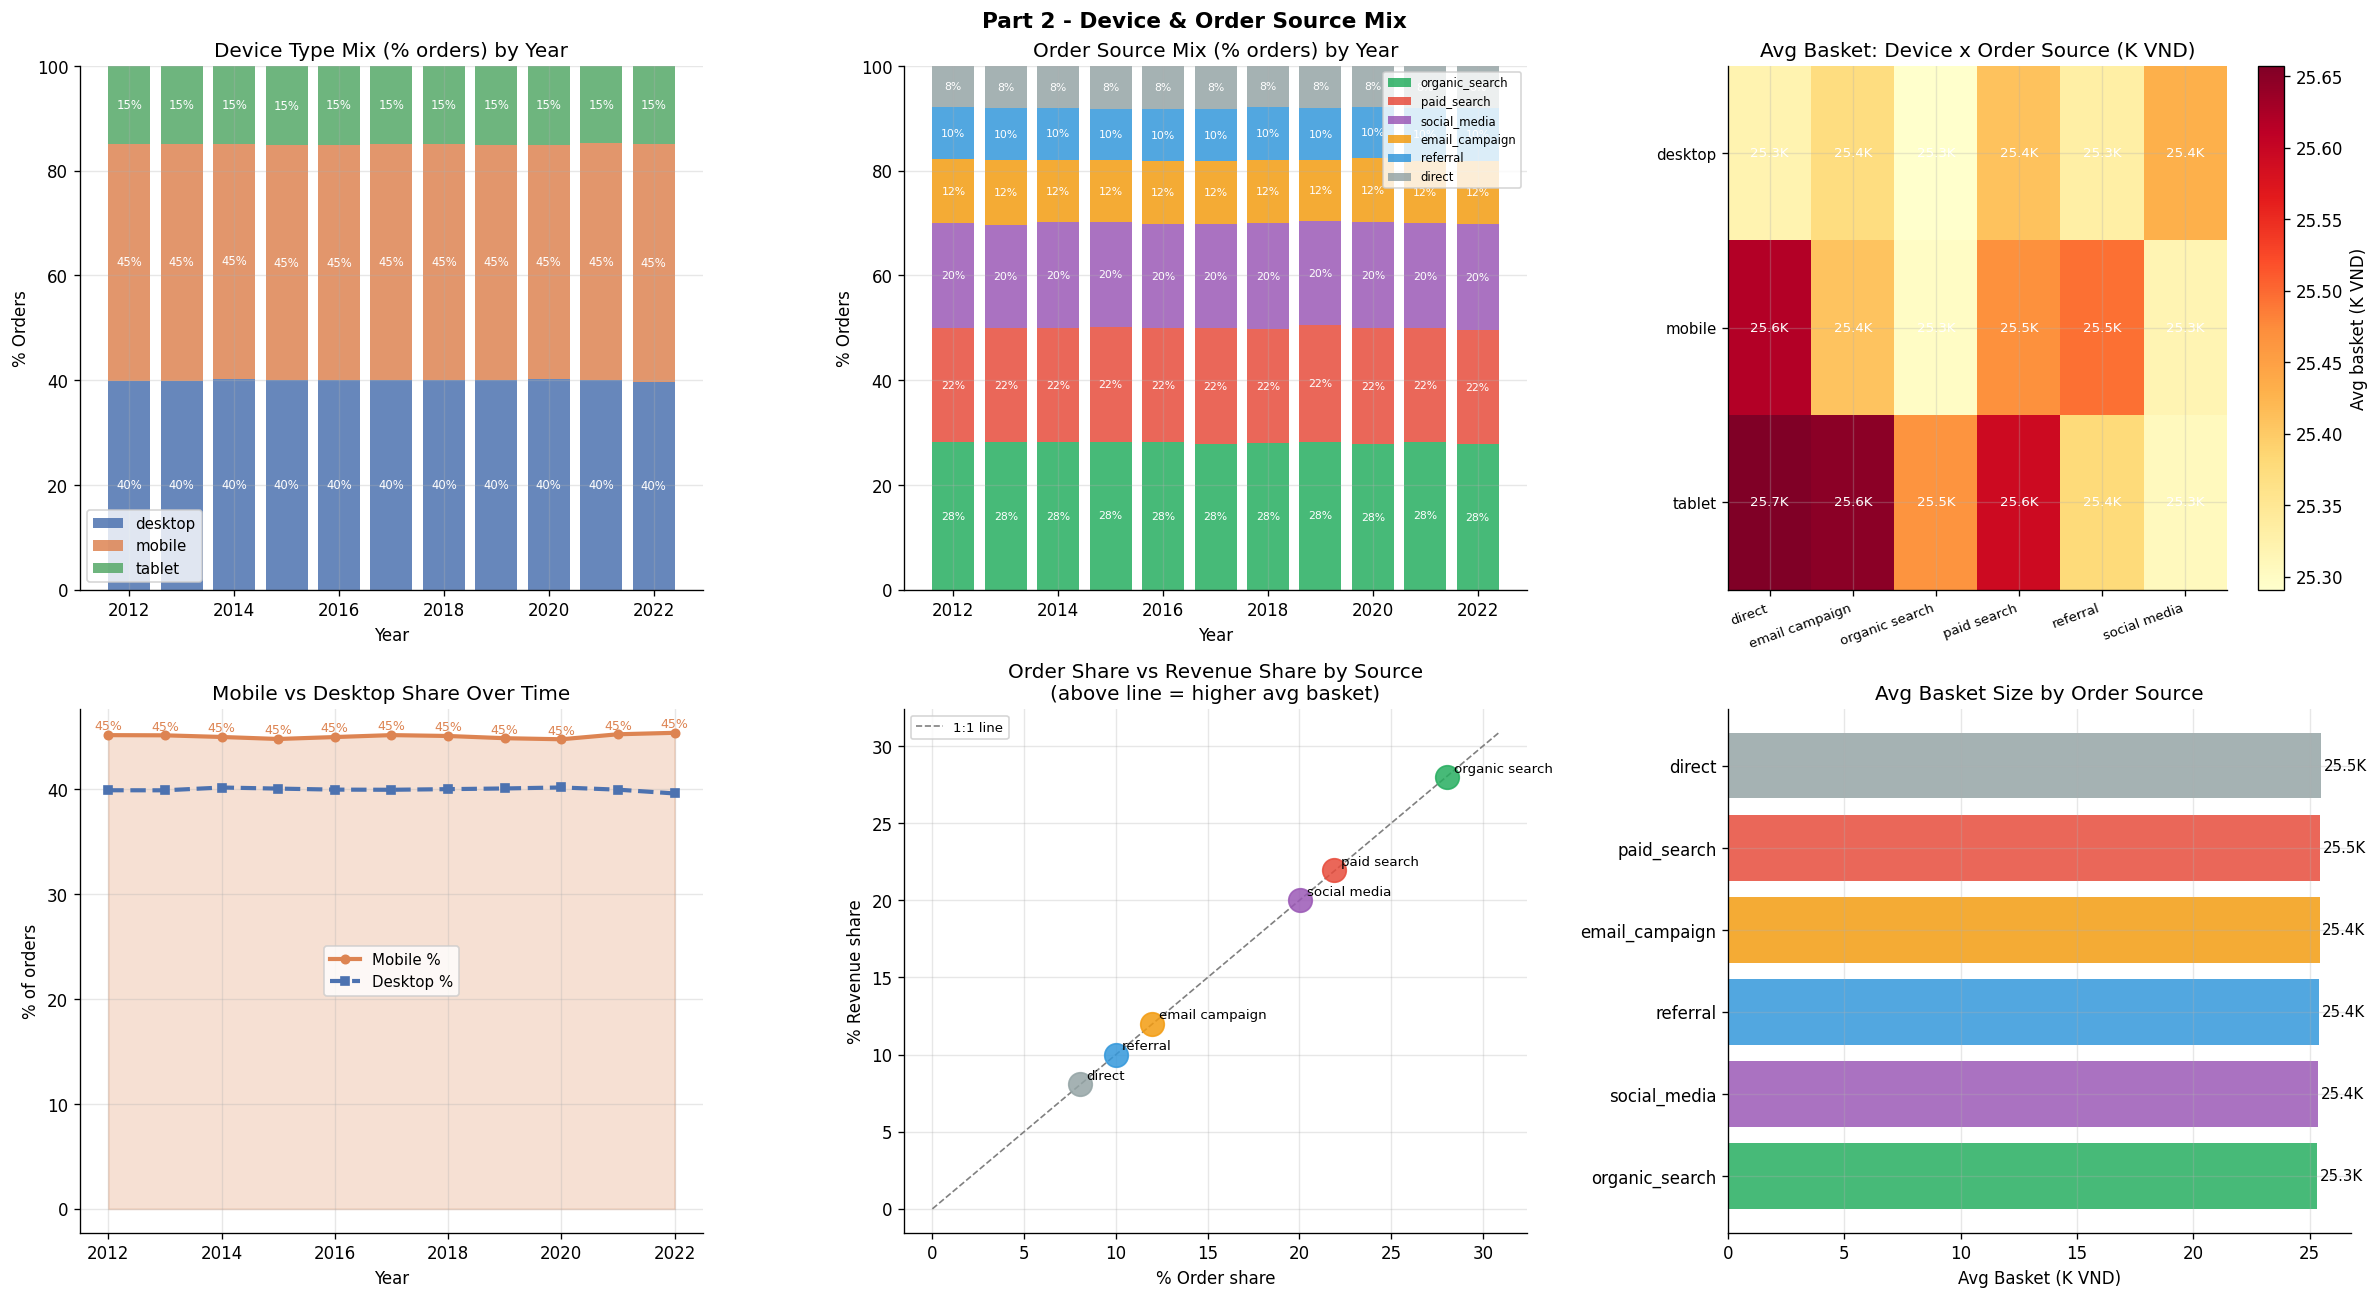

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# ── A: Device mix % stacked bar ───────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(dev_piv_pct))
for dev in ['desktop','mobile','tablet']:
    if dev not in dev_piv_pct.columns: continue
    vals = dev_piv_pct[dev].values
    ax.bar(dev_piv_pct.index, vals, bottom=bottom,
           color=DEV_COLORS.get(dev,'#aaa'), alpha=0.85, label=dev)
    for i, (yr, b, v) in enumerate(zip(dev_piv_pct.index, bottom, vals)):
        if v > 5:
            ax.text(yr, b+v/2, f'{v:.0f}%', ha='center', va='center', fontsize=7, color='white')
    bottom += vals
ax.set_xlabel('Year'); ax.set_ylabel('% Orders')
ax.set_title('Device Type Mix (% orders) by Year')
ax.legend(fontsize=9); ax.set_ylim(0,100)

# ── B: Order source mix % stacked bar ─────────────────────────────────────────
ax = axes[1]
bottom2 = np.zeros(len(src_piv_pct))
for src in SOURCES:
    if src not in src_piv_pct.columns: continue
    vals2 = src_piv_pct[src].values
    ax.bar(src_piv_pct.index, vals2, bottom=bottom2,
           color=SRC_COLORS.get(src,'#aaa'), alpha=0.85, label=src)
    for i, (yr, b, v) in enumerate(zip(src_piv_pct.index, bottom2, vals2)):
        if v > 7:
            ax.text(yr, b+v/2, f'{v:.0f}%', ha='center', va='center', fontsize=6.5, color='white')
    bottom2 += vals2
ax.set_xlabel('Year'); ax.set_ylabel('% Orders')
ax.set_title('Order Source Mix (% orders) by Year')
ax.legend(fontsize=7, loc='upper right'); ax.set_ylim(0,100)

# ── C: Avg basket by device x source heatmap ─────────────────────────────────
ax = axes[2]
im = ax.imshow(dev_src.values/1e3, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(dev_src.columns)))
ax.set_xticklabels([c.replace('_',' ') for c in dev_src.columns], fontsize=8, rotation=20, ha='right')
ax.set_yticks(range(len(dev_src.index)))
ax.set_yticklabels(dev_src.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Avg basket (K VND)')
for i in range(dev_src.shape[0]):
    for j in range(dev_src.shape[1]):
        v = dev_src.values[i,j]
        ax.text(j, i, f'{v/1e3:.1f}K', ha='center', va='center', fontsize=8,
                color='white' if v > dev_src.values.max()*0.7 else 'black')
ax.set_title('Avg Basket: Device x Order Source (K VND)')

# ── D: Mobile share trend (highlight) ────────────────────────────────────────
ax = axes[3]
if 'mobile' in dev_piv_pct.columns:
    mob = dev_piv_pct['mobile']
    ax.fill_between(mob.index, mob.values, alpha=0.25, color='#DD8452')
    ax.plot(mob.index, mob.values, color='#DD8452', lw=2.5, marker='o', ms=5, label='Mobile %')
if 'desktop' in dev_piv_pct.columns:
    dsk = dev_piv_pct['desktop']
    ax.plot(dsk.index, dsk.values, color='#4C72B0', lw=2.5, marker='s',
            ms=5, linestyle='--', label='Desktop %')
ax.set_xlabel('Year'); ax.set_ylabel('% of orders')
ax.set_title('Mobile vs Desktop Share Over Time')
ax.legend(fontsize=9)
for x, y in zip(mob.index, mob.values):
    ax.text(x, y+0.5, f'{y:.0f}%', ha='center', fontsize=7.5, color='#DD8452')

# ── E: Revenue share vs order share by source (efficiency) ───────────────────
ax = axes[4]
for i, (_, row) in enumerate(src_summary.iterrows()):
    order_share = row['n_orders']/src_summary['n_orders'].sum()*100
    ax.scatter(order_share, row['rev_share'], s=200, alpha=0.85,
               color=SRC_COLORS.get(row['order_source'],'#aaa'), zorder=3)
    ax.annotate(row['order_source'].replace('_',' '),
                (order_share, row['rev_share']),
                fontsize=8, xytext=(4,3), textcoords='offset points')
xmax = src_summary['n_orders'].max()/src_summary['n_orders'].sum()*100 * 1.1
ax.plot([0,xmax],[0,xmax], color='grey', lw=1, linestyle='--', label='1:1 line')
ax.set_xlabel('% Order share'); ax.set_ylabel('% Revenue share')
ax.set_title('Order Share vs Revenue Share by Source\n(above line = higher avg basket)')
ax.legend(fontsize=8)

# ── F: Avg basket by source bar ───────────────────────────────────────────────
ax = axes[5]
src_s = src_summary.sort_values('avg_basket', ascending=True)
colors_s = [SRC_COLORS.get(s,'#aaa') for s in src_s['order_source']]
bars = ax.barh(src_s['order_source'], src_s['avg_basket']/1e3, color=colors_s, alpha=0.85)
ax.set_xlabel('Avg Basket (K VND)')
ax.set_title('Avg Basket Size by Order Source')
for bar, val in zip(bars, src_s['avg_basket']):
    ax.text(val/1e3+0.1, bar.get_y()+bar.get_height()/2,
            f'{val/1e3:.1f}K', va='center', fontsize=9)

plt.suptitle('Part 2 - Device & Order Source Mix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dig_p2_device_source.png', bbox_inches='tight')
plt.show()


## Part 3 · Payment Behaviour & Installment Uptake
> Dac biet: installments=2 co anomaly ro rang (avg basket ~779 VND thay vi ~25K). Kiem tra xem installment uptake co tuong quan voi basket size khong.

In [6]:
# ── Payment method mix ────────────────────────────────────────────────────────
pay_full = pays.merge(ord_basket, on='order_id', how='left')
pay_full = pay_full.merge(orders[['order_id','order_date']], on='order_id', how='left')
pay_full['year'] = pd.to_datetime(pay_full['order_date']).dt.year
pay_full['uses_installment'] = (pay_full['installments'] > 1).astype(int)

pay_summary = pay_full.groupby('payment_method').agg(
    n_orders     = ('order_id','count'),
    avg_basket   = ('basket_size','mean'),
    avg_payval   = ('payment_value','mean'),
    avg_install  = ('installments','mean'),
    pct_install  = ('uses_installment','mean'),
).reset_index().sort_values('n_orders', ascending=False)
pay_summary['pct_install'] *= 100
pay_summary['rev_share'] = (pay_summary['n_orders']/pay_summary['n_orders'].sum()*100)

print('=== Payment Method Summary ===')
pd.set_option('display.float_format','{:.1f}'.format,'display.width',160)
print(pay_summary.to_string(index=False))
print()

# ── Installment uptake by year ────────────────────────────────────────────────
install_yr = pay_full.groupby('year').agg(
    n_orders     = ('order_id','count'),
    pct_install  = ('uses_installment','mean'),
    avg_install_plans = ('installments', lambda x: x[x>1].mean() if (x>1).any() else 1),
    avg_basket_install = ('basket_size', lambda x: x[pay_full.loc[x.index,'uses_installment']==1].mean()),
    avg_basket_cash    = ('basket_size', lambda x: x[pay_full.loc[x.index,'uses_installment']==0].mean()),
).reset_index()
install_yr['pct_install'] *= 100

print('=== Installment Uptake by Year ===')
print(install_yr.to_string(index=False))
print()

# ── Installment plan x basket size ───────────────────────────────────────────
install_basket = pay_full.groupby('installments').agg(
    n_orders    = ('order_id','count'),
    avg_basket  = ('basket_size','mean'),
    med_basket  = ('basket_size','median'),
    avg_payval  = ('payment_value','mean'),
    pct_of_all  = ('order_id','count'),
).reset_index()
install_basket['pct_of_all'] = install_basket['n_orders']/len(pay_full)*100

print('=== Installment Plan vs Basket Size ===')
print(install_basket.to_string(index=False))
print()

# ── ANOMALY: installments=2 has near-zero basket ─────────────────────────────
inst2 = pay_full[pay_full['installments']==2]
print(f'=== ANOMALY: installments=2 (n={len(inst2):,}) ===')
print(f'avg basket : {inst2["basket_size"].mean():.1f} VND  (expected ~25K)')
print(f'avg payval : {inst2["payment_value"].mean():.1f} VND')
print(f'basket==0  : {(inst2["basket_size"]==0).sum()} orders')
print(f'basket<100 : {(inst2["basket_size"]<100).sum()} orders')
print(f'payment_method: {inst2["payment_method"].value_counts().to_dict()}')
print(f'year dist  : {inst2["year"].value_counts().sort_index().to_dict()}')
print()
print('Sample rows:')
print(inst2[['order_id','installments','basket_size','payment_value','payment_method','year']].head(10).to_string(index=False))

# ── Basket size distribution by installment plan (excl. plan=2 anomaly) ──────
print()
install_bucket = pay_full[pay_full['installments']!=2].copy()
install_bucket['basket_bucket'] = pd.cut(
    install_bucket['basket_size'],
    bins=[0,10000,20000,30000,50000,100000,999999999],
    labels=['<10K','10-20K','20-30K','30-50K','50-100K','>100K']
)
uptake = install_bucket.groupby(['basket_bucket','installments']).size().unstack(fill_value=0)
uptake_pct = uptake.div(uptake.sum(axis=1), axis=0)*100
print('=== Installment Choice by Basket Bucket (%, excl plan=2) ===')
print(uptake_pct.round(1).to_string())


=== Payment Method Summary ===
payment_method  n_orders  avg_basket  avg_payval  avg_install  pct_install  rev_share
   credit_card    356352     25374.8     24217.8          3.9         69.8       55.1
        paypal     97018     25542.7     24363.3          3.9         69.7       15.0
           cod     96681     25426.9     24275.2          1.0          0.0       14.9
     apple_pay     64763     25301.1     24153.8          3.9         70.0       10.0
 bank_transfer     32131     25306.6     24148.1          3.9         69.2        5.0

=== Installment Uptake by Year ===
 year  n_orders  pct_install  avg_install_plans  avg_basket_install  avg_basket_cash
 2012     32051         59.1                5.1             23157.3          23102.6
 2013     76849         59.3                5.1             21776.9          21254.2
 2014     80645         59.0                5.1             23308.0          23071.1
 2015     82622         59.4                5.1             23008.0          

=== Installment Plan vs Basket Size ===
 installments  n_orders  avg_basket  med_basket  avg_payval  pct_of_all
            1    262866     25263.5     18126.6     24113.3        40.6
            2      1094       779.3       794.8       708.5         0.2
            3    218949     25561.7     18431.1     24399.6        33.8
            6    109910     25624.7     18523.4     24446.7        17.0
           12     54126     25414.8     18377.5     24245.8         8.4

=== ANOMALY: installments=2 (n=1,094) ===
avg basket : 779.3 VND  (expected ~25K)
avg payval : 708.5 VND
basket==0  : 0 orders
basket<100 : 0 orders
payment_method: {'credit_card': 742, 'paypal': 182, 'apple_pay': 105, 'bank_transfer': 65}
year dist  : {2012: 82, 2013: 219, 2014: 179, 2015: 188, 2016: 130, 2017: 94, 2018: 80, 2019: 35, 2020: 30, 2021: 26, 2022: 31}

Sample rows:
 order_id  installments  basket_size  payment_value payment_method  year
      534             2        902.7          902.7    credit_card  2012

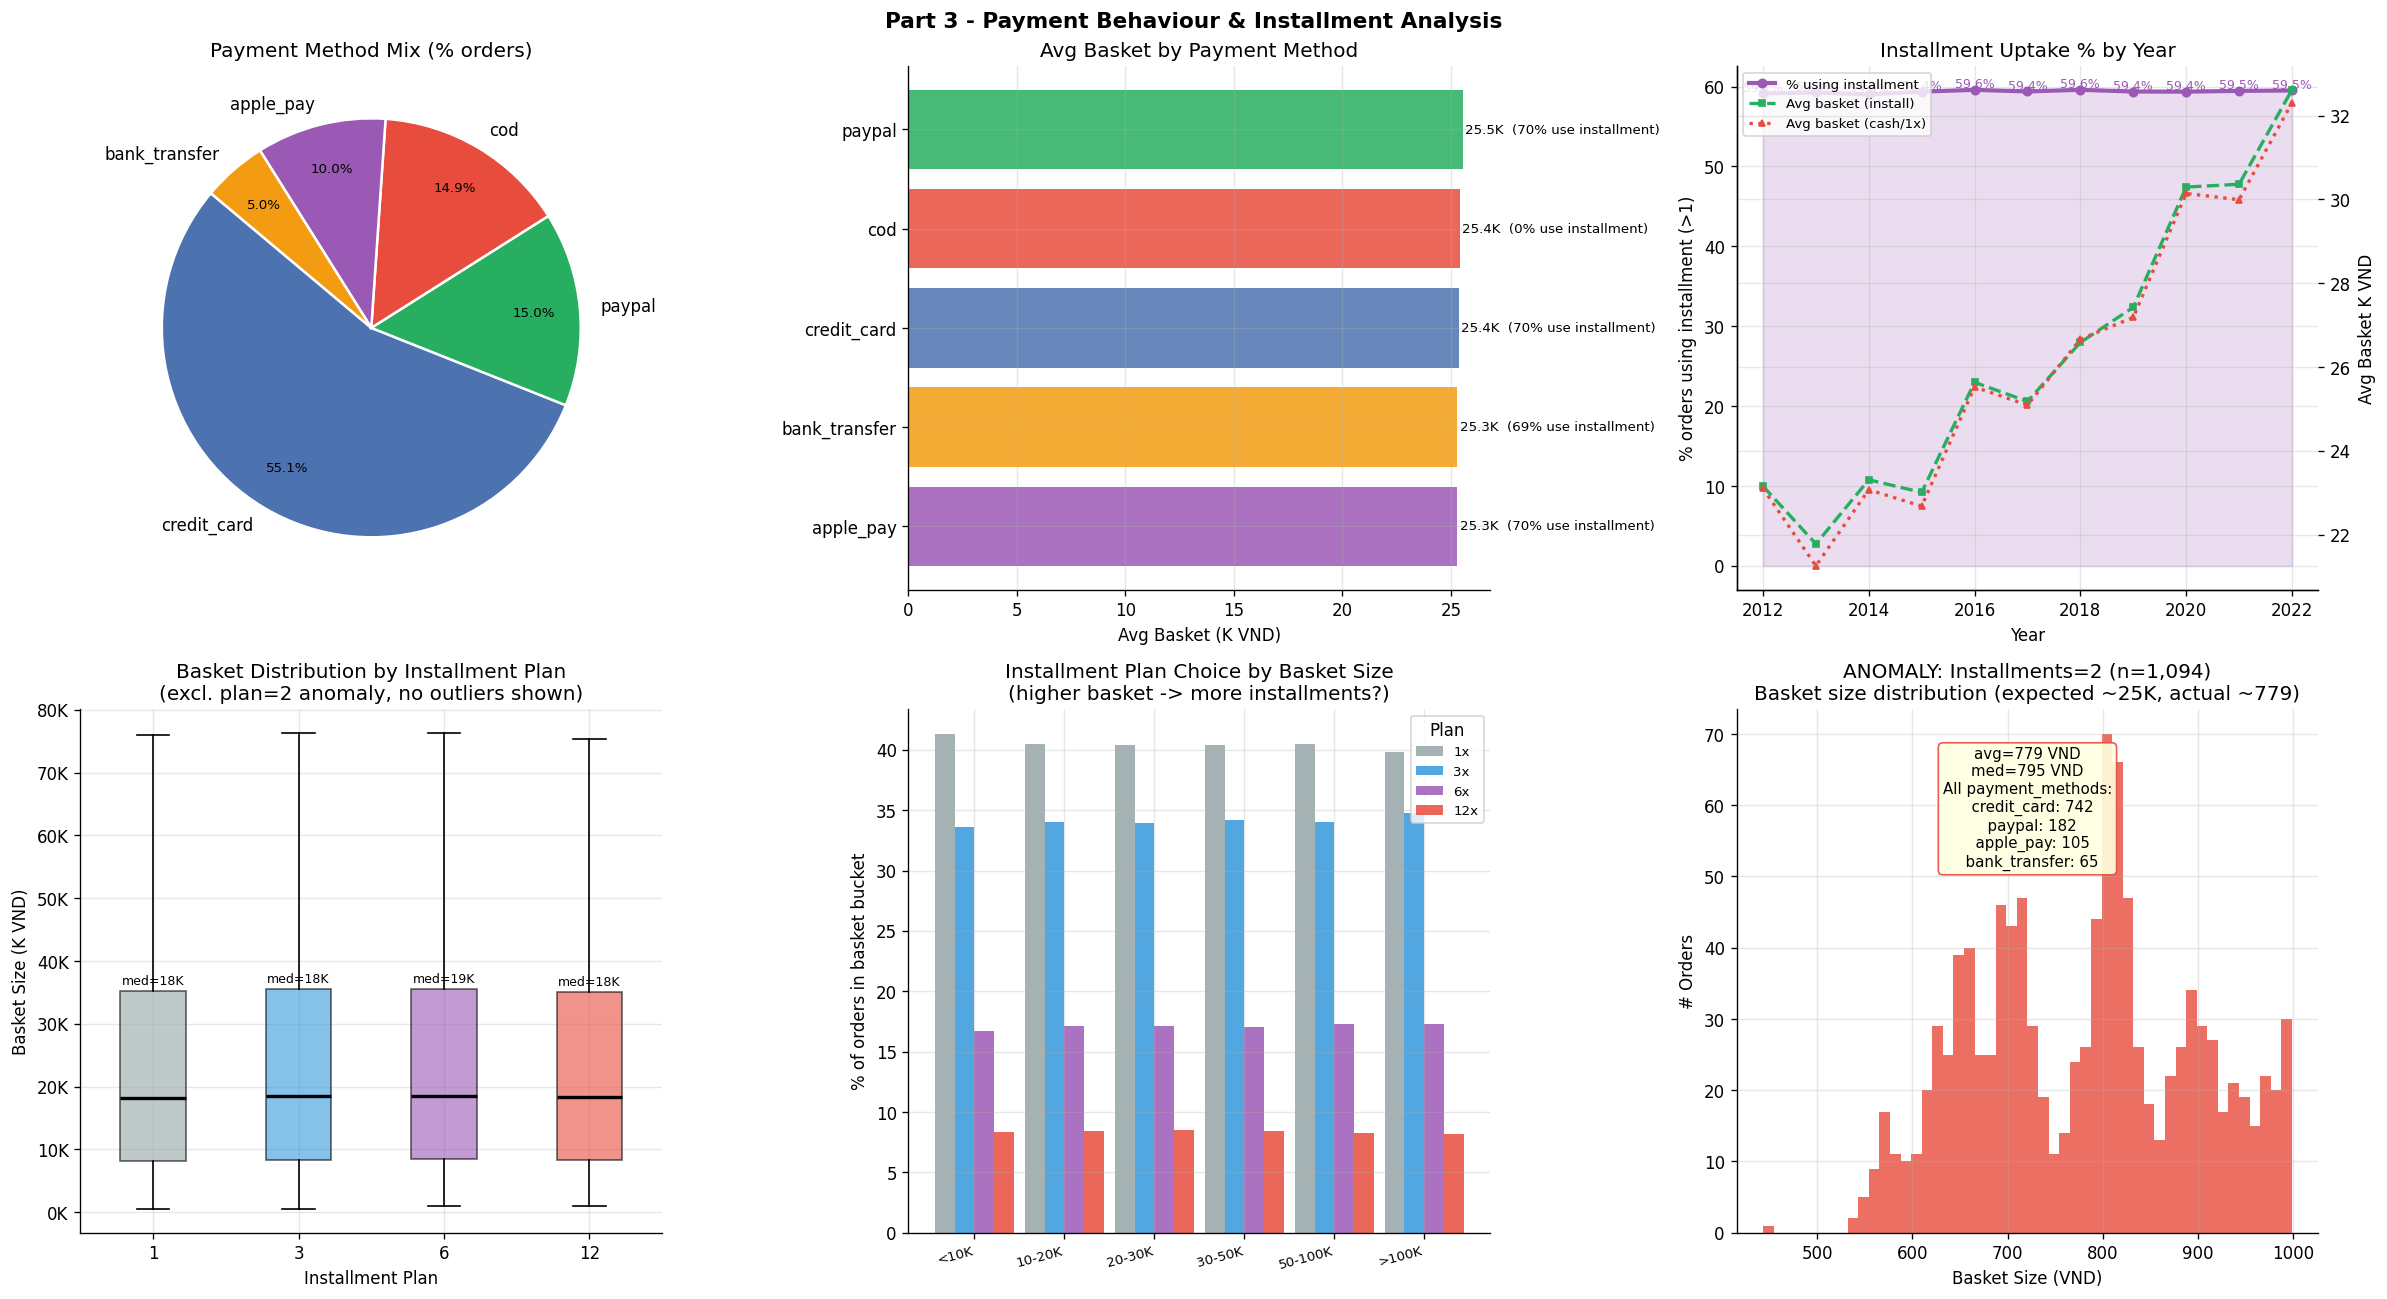

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# ── A: Payment method mix pie ─────────────────────────────────────────────────
ax = axes[0]
colors_p = [PAY_COLORS.get(m,'#aaa') for m in pay_summary['payment_method']]
wedges, texts, autos = ax.pie(
    pay_summary['n_orders'], labels=pay_summary['payment_method'],
    autopct='%1.1f%%', colors=colors_p, startangle=140,
    pctdistance=0.78, wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autos: at.set_fontsize(8)
ax.set_title('Payment Method Mix (% orders)')

# ── B: Avg basket by payment method ──────────────────────────────────────────
ax = axes[1]
pm_s = pay_summary.sort_values('avg_basket', ascending=True)
colors_pm = [PAY_COLORS.get(m,'#aaa') for m in pm_s['payment_method']]
bars = ax.barh(pm_s['payment_method'], pm_s['avg_basket']/1e3,
               color=colors_pm, alpha=0.85)
ax.set_xlabel('Avg Basket (K VND)')
ax.set_title('Avg Basket by Payment Method')
for bar, (_, row) in zip(bars, pm_s.iterrows()):
    ax.text(row['avg_basket']/1e3+0.1, bar.get_y()+bar.get_height()/2,
            f'{row["avg_basket"]/1e3:.1f}K  ({row["pct_install"]:.0f}% use installment)',
            va='center', fontsize=8)

# ── C: Installment uptake % by year ──────────────────────────────────────────
ax = axes[2]
ax.fill_between(install_yr['year'], install_yr['pct_install'], alpha=0.2, color='#9b59b6')
ax.plot(install_yr['year'], install_yr['pct_install'],
        color='#9b59b6', lw=2.5, marker='o', ms=5, label='% using installment')
ax.set_xlabel('Year'); ax.set_ylabel('% orders using installment (>1)')
ax.set_title('Installment Uptake % by Year')
ax2c = ax.twinx()
ax2c.plot(install_yr['year'], install_yr['avg_basket_install']/1e3,
          color='#27ae60', lw=2, marker='s', ms=4, linestyle='--', label='Avg basket (install)')
ax2c.plot(install_yr['year'], install_yr['avg_basket_cash']/1e3,
          color='#e74c3c', lw=2, marker='^', ms=4, linestyle=':', label='Avg basket (cash/1x)')
ax2c.set_ylabel('Avg Basket K VND')
lines1,labs1 = ax.get_legend_handles_labels()
lines2,labs2 = ax2c.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper left')
for x,y in zip(install_yr['year'], install_yr['pct_install']):
    ax.text(x, y+0.3, f'{y:.1f}%', ha='center', fontsize=7.5, color='#9b59b6')

# ── D: Installment plan (3/6/12) vs basket size violin-like ───────────────────
ax = axes[3]
plan_data = pay_full[pay_full['installments'].isin([1,3,6,12])]
plan_labels = [1,3,6,12]
plan_vals = [plan_data[plan_data['installments']==p]['basket_size'].values/1e3 for p in plan_labels]
bp = ax.boxplot(plan_vals, labels=plan_labels, patch_artist=True,
                medianprops=dict(color='black',lw=2), showfliers=False)
PLAN_COLORS = ['#95a5a6','#3498db','#9b59b6','#e74c3c']
for patch, color in zip(bp['boxes'], PLAN_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xlabel('Installment Plan'); ax.set_ylabel('Basket Size (K VND)')
ax.set_title('Basket Distribution by Installment Plan\n(excl. plan=2 anomaly, no outliers shown)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))
for i, (p, vals) in enumerate(zip(plan_labels, plan_vals)):
    ax.text(i+1, np.percentile(vals,75)+1, f'med={np.median(vals):.0f}K', ha='center', fontsize=7.5)

# ── E: Installment choice % by basket bucket ──────────────────────────────────
ax = axes[4]
buckets = uptake_pct.index.tolist()
x = np.arange(len(buckets))
w = 0.22
PLAN_COLS2 = {'1':'#95a5a6','3':'#3498db','6':'#9b59b6','12':'#e74c3c'}
for i, plan in enumerate([1,3,6,12]):
    if plan in uptake_pct.columns:
        ax.bar(x + (i-1.5)*w, uptake_pct[plan].values, w,
               color=PLAN_COLS2[str(plan)], alpha=0.85, label=f'{plan}x')
ax.set_xticks(x); ax.set_xticklabels(buckets, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('% of orders in basket bucket')
ax.set_title('Installment Plan Choice by Basket Size\n(higher basket -> more installments?)')
ax.legend(title='Plan', fontsize=8)

# ── F: ANOMALY plan=2 — basket dist ───────────────────────────────────────────
ax = axes[5]
ax.hist(inst2['basket_size'], bins=50, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Basket Size (VND)'); ax.set_ylabel('# Orders')
ax.set_title(f'ANOMALY: Installments=2 (n={len(inst2):,})\nBasket size distribution (expected ~25K, actual ~779)')
ax.text(0.5, 0.7,
        f'avg={inst2["basket_size"].mean():.0f} VND\n'
        f'med={inst2["basket_size"].median():.0f} VND\n'
        f'All payment_methods:\n'+
        '\n'.join([f'  {k}: {v}' for k,v in inst2["payment_method"].value_counts().items()]),
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round',fc='lightyellow',ec='#e74c3c',alpha=0.9))

plt.suptitle('Part 3 - Payment Behaviour & Installment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dig_p3_payment.png', bbox_inches='tight')
plt.show()


## Summary

In [8]:
print('='*65)
print('DIGITAL CHANNELS & PAYMENT SUMMARY')
print('='*65)
print()
print('=== Web Traffic ===')
latest = web_yr.iloc[-1]
first  = web_yr.iloc[0]
print(f'  Sessions 2013     : {first["sessions"]:,.0f}  (avg/day: {first["sessions"]/365:.0f})')
print(f'  Sessions 2022     : {latest["sessions"]:,.0f}  (avg/day: {latest["sessions"]/365:.0f})')
print(f'  Growth            : {(latest["sessions"]/first["sessions"]-1)*100:+.1f}%')
print(f'  Bounce rate 2022  : {latest["bounce"]*100:.3f}%')
print(f'  Avg session dur   : {latest["duration"]:.0f}s')
print()
print('=== Conversion Proxy ===')
for _, row in conv_yr.iterrows():
    print(f'  {int(row["year"])}: {row["conv_proxy_pct"]:.3f}%  ({int(row["total_orders"]):,} orders / {row["total_sessions"]/1e6:.1f}M sessions)')
print()
print('=== Device Mix (latest year) ===')
latest_dev = dev_piv_pct.iloc[-1]
for dev, pct in latest_dev.items():
    print(f'  {dev:10s}: {pct:.1f}%')
print()
print('=== Payment ===')
for _, row in pay_summary.iterrows():
    print(f'  {row["payment_method"]:15s}: {row["n_orders"]:>7,} orders  '
          f'avg_basket={row["avg_basket"]/1e3:.1f}K  install={row["pct_install"]:.0f}%')
print()
total_install = (pays['installments']>1).sum()
print(f'  Overall installment uptake: {total_install:,} / {len(pays):,} = {total_install/len(pays)*100:.1f}%')
print(f'  ANOMALY plan=2: {len(inst2):,} orders, avg basket={inst2["basket_size"].mean():.0f} VND (data issue)')


DIGITAL CHANNELS & PAYMENT SUMMARY

=== Web Traffic ===
  Sessions 2013     : 6,801,940  (avg/day: 18635)
  Sessions 2022     : 11,063,658  (avg/day: 30311)
  Growth            : +62.7%
  Bounce rate 2022  : 0.449%
  Avg session dur   : 213s

=== Conversion Proxy ===
  2013: 0.227%  (15,412 orders / 6.8M sessions)
  2014: 0.218%  (16,030 orders / 7.3M sessions)
  2015: 0.214%  (16,848 orders / 7.9M sessions)
  2016: 0.192%  (16,167 orders / 8.4M sessions)
  2017: 0.162%  (14,528 orders / 9.0M sessions)
  2018: 0.144%  (13,534 orders / 9.4M sessions)
  2019: 0.082%  (8,162 orders / 10.0M sessions)
  2020: 0.063%  (6,700 orders / 10.6M sessions)
  2021: 0.061%  (6,714 orders / 11.0M sessions)
  2022: 0.068%  (7,491 orders / 11.1M sessions)

=== Device Mix (latest year) ===
  desktop   : 39.6%
  mobile    : 45.4%
  tablet    : 15.0%

=== Payment ===
  credit_card    : 356,352 orders  avg_basket=25.4K  install=70%
  paypal         :  97,018 orders  avg_basket=25.5K  install=70%
  cod      